# 选股＋双均线择时＋风险仓位＋回测

这是一篇可独立运行的 A 股小实验：**API 获取数据 → PE 选 10 只 → MA5/MA20 双均线 → 按风险分三次建仓 → 浮动止盈/止损 → 与沪深 300 比较**。所有必要代码都在本笔记本内。

研究区间为 **2026-01-05 至 2026-09-30**，模拟本金 **10 万元**。每 7 个交易日从固定的沪深 300 成分股中选 10 只。下面的百分比风险预算是对**入场时预估损失**的约束，不是账户亏损上限：跳空、停牌和下一开盘成交都会让实际亏损超过预算。

## 模块 0｜准备：安装和统一参数

在 Python 3.10+ 环境安装 `pip install pandas numpy matplotlib Pillow baostock ipython`。本例不需要行情付费账号；但 BaoStock 需要能访问其 TCP 服务，东方财富需要 HTTPS 网络。把原始数据存在相对目录 `data/private/`，下次运行直接读缓存。

In [1]:
import json
import time
import urllib.parse
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image as NotebookImage

DATA = Path('data/private')
DATA.mkdir(parents=True, exist_ok=True)
START_DATE, FIRST_DAY, END_DATE = '2025-12-01', '2026-01-05', '2026-09-30'
POOL_SIZE, PE_LOWER, PE_UPPER = 10, 8.0, 30.0
MA_FAST, MA_SLOW, ATR_WINDOW = 5, 20, 14
INITIAL_CASH = 100_000.0
COMMISSION_RATE, MIN_COMMISSION = 0.0003, 5.0   # 券商万三；每笔佣金最低 5 元
STAMP_DUTY_RATE = 0.0005                       # 2026 年卖出印花税：万分之五
TRANSFER_RATE = 0.00001                        # 过户费双边：十万分之一
TOTAL_RISK, NAME_RISK, MAX_NAME_WEIGHT = 0.01, 0.002, 0.10
RISK_BUFFER = 0.95  # 下单时只用 95% 的组合风险预算，给费用和净值波动留余量
INITIAL_STOP, ARM_GAIN, TRAIL_BACK = 0.03, 0.08, 0.03
ATR_MULT, TRANCHES, ADD_PROFIT_STEP = 2.0, 3, 0.02  # 两次加仓阈值：+2%、+4%
BAR_FIELDS = 'date,code,open,high,low,close,volume,amount,tradestatus,peTTM,isST'
REPORT_DATES = ('2025-09-30', '2025-12-31', '2026-03-31', '2026-06-30')
EASTMONEY_API = 'https://datacenter-web.eastmoney.com/api/data/v1/get'

font_path = Path('video/assets/NotoSansCJKsc-Regular.otf')
if font_path.exists():
    font_manager.fontManager.addfont(str(font_path))
    plt.rcParams['font.family'] = font_manager.FontProperties(fname=str(font_path)).get_name()
plt.rcParams['axes.unicode_minus'] = False

## 模块 1｜用 BaoStock API 获取日线和指数

先查询 **2026-01-05 的沪深 300 成分股**，把这 300 只作为固定研究范围；再逐只请求日 K 线。`adjustflag='1'` 表示**后复权**：适合近似比较跨分红送转的收益，但价格和“股数”不能直接拿来实盘下单。`peTTM` 是数据源给出的滚动市盈率；`tradestatus` 和 `isST` 帮助排除不能按规则交易的股票。2025-12-01 开始抓取，是给 MA20 留预热数据。

沪深 300（`sh.000300`）是本节**基准**；上证综指（`sh.000001`）仅作背景。指数用不复权值 `adjustflag='3'`。下面的函数在文件不存在时下载，已有缓存则直接读取。

In [2]:
def rows(result, label: str) -> pd.DataFrame:
    if result.error_code != "0":
        raise RuntimeError(f"{label}: {result.error_code} {result.error_msg}")
    records = []
    while result.next():
        records.append(result.get_row_data())
    return pd.DataFrame(records, columns=result.fields)


def load_or_fetch_baostock():
    names = ['simple_2026_members.csv.gz', 'simple_2026_bars.csv.gz',
             'simple_2026_benchmark.csv.gz', 'simple_2026_shanghai.csv.gz']
    paths = [DATA / name for name in names]
    if not all(path.exists() for path in paths):
        import baostock as bs
        login = bs.login()
        if login.error_code != '0':
            raise RuntimeError(f'BaoStock 登录失败：{login.error_msg}')
        try:
            members = rows(bs.query_hs300_stocks(date=FIRST_DAY), '沪深300成分股')
            codes = sorted(members.code.unique())
            if not 250 <= len(codes) <= 350:
                raise ValueError(f'成分股数量异常：{len(codes)}')
            parts = []
            for i, code in enumerate(codes, 1):
                result = bs.query_history_k_data_plus(
                    code, BAR_FIELDS, start_date=START_DATE,
                    end_date=END_DATE, frequency='d', adjustflag='1')
                parts.append(rows(result, code))
                if i % 50 == 0:
                    print(f'BaoStock 已获取 {i}/{len(codes)} 只')
            bars = pd.concat(parts, ignore_index=True)
            benchmark = rows(bs.query_history_k_data_plus(
                'sh.000300', 'date,code,open,close',
                start_date=START_DATE, end_date=END_DATE,
                frequency='d', adjustflag='3'), '沪深300指数')
            shanghai = rows(bs.query_history_k_data_plus(
                'sh.000001', 'date,code,open,close',
                start_date=START_DATE, end_date=END_DATE,
                frequency='d', adjustflag='3'), '上证综指')
        finally:
            bs.logout()
        for frame, path in zip((members, bars, benchmark, shanghai), paths):
            frame.to_csv(path, index=False, compression='gzip')
    members = pd.read_csv(paths[0], dtype={'code': str})
    bars = pd.read_csv(paths[1], dtype={'code': str})
    benchmark = pd.read_csv(paths[2])
    shanghai = pd.read_csv(paths[3])
    return members, bars, benchmark, shanghai

members_raw, bars_raw, benchmark_raw, shanghai_raw = load_or_fetch_baostock()
print(f'成分股 {len(members_raw)} 只；日线 {len(bars_raw):,} 行；最后交易日 {bars_raw.date.max()}')
display(bars_raw[['date', 'code', 'open', 'close', 'peTTM']].head(3))

成分股 300 只；日线 61,200 行；最后交易日 2026-09-30


,date,code,open,close,peTTM
0,2025-12-01,sh.600000,145.637137,147.296456,7.867467
1,2025-12-01,sh.600009,83.540100,84.547565,33.533784
2,2025-12-01,sh.600010,17.668255,18.030309,111.250461


## 模块 2｜用东方财富 API 获取财报

技术指标只看价格，基本面还要看财报。本例按报告期分页请求东方财富数据中心的 `RPT_LICO_FN_CPD`，只保留研究股票的公告日期、更新日期和每股收益（EPS）等字段。网页接口可能变化或限流；**报告期不是公布日期**，回测必须等到财报实际可用后才使用。东财历史网页会被修订，因此这仍不是严格的逐日历史快照。

In [3]:
def eastmoney_page(report_date: str, page: int, retries: int = 3) -> dict:
    params = {
        "sortColumns": "UPDATE_DATE,SECURITY_CODE",
        "sortTypes": "-1,-1",
        "pageSize": "500",
        "pageNumber": str(page),
        "reportName": "RPT_LICO_FN_CPD",
        "columns": "ALL",
        "filter": f"(REPORTDATE='{report_date}')",
    }
    url = EASTMONEY_API + "?" + urllib.parse.urlencode(params)
    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 MiniQuant educational snapshot",
            "Referer": "https://data.eastmoney.com/bbsj/",
        },
    )
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(request, timeout=20) as response:
                payload = json.load(response)
            if payload.get("success") is not True or not payload.get("result"):
                raise ValueError(f"Eastmoney response changed: {payload.get('message')}")
            return payload["result"]
        except (OSError, ValueError) as exc:
            if attempt == retries - 1:
                raise RuntimeError(f"Eastmoney {report_date} page {page}") from exc
            time.sleep(1.5 * (attempt + 1))
    raise AssertionError("unreachable")


def fetch_reports(codes: set[str]) -> pd.DataFrame:
    all_rows = []
    for report_date in REPORT_DATES:
        first = eastmoney_page(report_date, 1)
        pages = int(first["pages"])
        expected_count = int(first["count"])
        raw = list(first.get("data") or [])
        for page in range(2, pages + 1):
            raw.extend(eastmoney_page(report_date, page).get("data") or [])
            time.sleep(0.08)
        if len(raw) != expected_count:
            raise ValueError(f"Eastmoney {report_date}: expected {expected_count}, got {len(raw)}")
        kept = [r for r in raw if str(r.get("SECURITY_CODE", "")).zfill(6) in codes]
        all_rows.extend(kept)
        print(f"Eastmoney {report_date}: {len(raw)} raw / {len(kept)} in universe", flush=True)
    if not all_rows:
        raise ValueError("No reports matched the chosen stocks")
    out = pd.DataFrame(all_rows)
    keep = [
        "SECURITY_CODE", "SECURITY_NAME_ABBR", "TRADE_MARKET", "REPORTDATE",
        "NOTICE_DATE", "UPDATE_DATE", "BASIC_EPS", "PARENT_NETPROFIT",
        "TOTAL_OPERATE_INCOME", "BOARD_NAME",
    ]
    missing = set(keep).difference(out.columns)
    if missing:
        raise ValueError(f"Eastmoney missing columns: {sorted(missing)}")
    return out[keep]


def load_or_fetch_reports(members):
    path = DATA / 'simple_2026_reports.csv.gz'
    if not path.exists():
        codes = {code.split('.')[-1] for code in members.code}
        fetch_reports(codes).to_csv(path, index=False, compression='gzip')
    return pd.read_csv(path, dtype={'SECURITY_CODE': str})

reports_raw = load_or_fetch_reports(members_raw)
print(f'财报 {len(reports_raw):,} 行；示例字段：')
display(reports_raw[['SECURITY_CODE', 'REPORTDATE', 'NOTICE_DATE',
                     'UPDATE_DATE', 'BASIC_EPS']].head(3))

财报 1,200 行；示例字段：


,SECURITY_CODE,REPORTDATE,NOTICE_DATE,UPDATE_DATE,BASIC_EPS
0,000858,2025-09-30 00:00:00,2025-10-31 00:00:00,2026-04-30 00:00:00,1.6680
1,300122,2025-09-30 00:00:00,2025-10-30 00:00:00,2026-04-28 00:00:00,-0.5547
2,688981,2025-09-30 00:00:00,2025-11-14 00:00:00,2025-11-14 00:00:00,0.4800


## 模块 3｜清洗数据，计算双均线和波动

真实接口的数字常是字符串，也可能有空值、重复或异常价格。下面校验日线与财报；分别计算 MA5、MA20、金叉/死叉，以及 ATR14（日均真实波幅）。ATR 只用于**保守估计仓位大小**：同样的风险预算，波动大的股票买得少。

**PE（市盈率）≈ 股价 ÷ 过去 12 个月每股收益**。股价 10 元、过去一年每股赚 1 元，PE 约 10 倍。`peTTM` 的 TTM 指滚动 12 个月。低 PE 不必然是好股票；表中的后复权 `close` 也不能直接与单季度 EPS 相除来重算 PE。

In [4]:
def clean_inputs(bars, reports, members, benchmark, ma_window=MA_SLOW):
    """Apply an explicit schema; return clean tables and a small rejection audit."""
    if ma_window < 2:
        raise ValueError("ma_window must be at least 2")
    bars = bars.copy()
    reports = reports.copy()
    members = members.copy()
    benchmark = benchmark.copy()
    audit = {}

    if bars.duplicated(["date", "code"]).any():
        raise ValueError("BaoStock date/code is not unique")
    bars["date"] = pd.to_datetime(bars["date"], errors="coerce")
    for col in ("open", "high", "low", "close", "volume", "amount", "peTTM"):
        bars[col] = pd.to_numeric(bars[col], errors="coerce")
    for col in ("tradestatus", "isST"):
        bars[col] = pd.to_numeric(bars[col], errors="coerce")
    invalid_price = (
        bars["date"].isna() | (bars[["open", "high", "low", "close"]] <= 0).any(axis=1)
        | (bars["high"] < bars[["open", "close"]].max(axis=1))
        | (bars["low"] > bars[["open", "close"]].min(axis=1))
        | (bars["volume"] < 0)
    )
    audit["bad_price_rows"] = int(invalid_price.sum())
    if invalid_price.any():
        raise ValueError(f"Invalid OHLC/volume in {invalid_price.sum()} rows")
    audit["suspended_rows"] = int((bars["tradestatus"] != 1).sum())
    audit["invalid_pe_rows"] = int((~bars["peTTM"].between(PE_LOWER, PE_UPPER, inclusive="neither")).sum())
    bars = bars.sort_values(["code", "date"]).reset_index(drop=True)
    group = bars.groupby('code', sort=False)['close']
    bars['fast_ma'] = group.transform(lambda x: x.rolling(MA_FAST, min_periods=MA_FAST).mean())
    bars['slow_ma'] = group.transform(lambda x: x.rolling(ma_window, min_periods=ma_window).mean())
    bars['prev_close'] = group.shift(1)
    bars['prev_fast'] = bars.groupby('code', sort=False)['fast_ma'].shift(1)
    bars['prev_slow'] = bars.groupby('code', sort=False)['slow_ma'].shift(1)
    true_range = pd.concat([
        bars.high - bars.low,
        (bars.high - bars.prev_close).abs(),
        (bars.low - bars.prev_close).abs(),
    ], axis=1).max(axis=1)
    bars['true_range'] = true_range
    bars['atr14'] = bars.groupby('code', sort=False)['true_range'].transform(
        lambda x: x.rolling(ATR_WINDOW, min_periods=ATR_WINDOW).mean())
    tradable = bars.tradestatus.eq(1) & bars.volume.gt(0)
    bars['golden_cross'] = (tradable & bars.fast_ma.gt(bars.slow_ma)
                            & bars.prev_fast.le(bars.prev_slow))
    bars['dead_cross'] = (tradable & bars.fast_ma.lt(bars.slow_ma)
                          & bars.prev_fast.ge(bars.prev_slow))

    reports["code6"] = reports["SECURITY_CODE"].str.zfill(6)
    for col in ("REPORTDATE", "NOTICE_DATE", "UPDATE_DATE"):
        reports[col] = pd.to_datetime(reports[col], errors="coerce").dt.normalize()
    for col in ("BASIC_EPS", "PARENT_NETPROFIT", "TOTAL_OPERATE_INCOME"):
        reports[col] = pd.to_numeric(reports[col], errors="coerce")
    bad_report = (
        ~reports["code6"].str.fullmatch(r"\d{6}", na=False)
        | reports[["REPORTDATE", "NOTICE_DATE", "UPDATE_DATE"]].isna().any(axis=1)
        | (reports["REPORTDATE"] > reports["NOTICE_DATE"])
    )
    audit["bad_report_rows"] = int(bad_report.sum())
    reports = reports.loc[~bad_report].copy()
    # A retrospective correction can change a value. Use the later date as a
    # conservative *earliest usable* date; this is still not a true PIT archive.
    reports["available_on"] = reports[["NOTICE_DATE", "UPDATE_DATE"]].max(axis=1)
    audit["missing_eps_rows"] = int(reports["BASIC_EPS"].isna().sum())
    reports = reports.drop_duplicates(["code6", "REPORTDATE", "available_on"], keep="last")

    members = members.drop_duplicates("code")
    if len(members) != 300:
        raise ValueError(f"Expected 300 fixed index constituents, got {len(members)}")
    if not set(bars["code"]).issubset(set(members["code"])):
        raise ValueError("Price data contains stocks outside the fixed CSI 300 universe")
    benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")
    for col in ("open", "close"):
        benchmark[col] = pd.to_numeric(benchmark[col], errors="coerce")
    if benchmark["date"].isna().any() or (benchmark[["open", "close"]] <= 0).any().any():
        raise ValueError("Bad benchmark date/price")
    benchmark = benchmark.drop_duplicates("date").sort_values("date").reset_index(drop=True)
    return bars, reports, members, benchmark, audit


bars, reports, members, benchmark, audit = clean_inputs(
    bars_raw, reports_raw, members_raw, benchmark_raw)
print('清洗审计：', audit)
print('可用日线：', bars.date.min().date(), '至', bars.date.max().date())

清洗审计： {'bad_price_rows': 0, 'suspended_rows': 98, 'invalid_pe_rows': 29793, 'bad_report_rows': 0, 'missing_eps_rows': 0}
可用日线： 2025-12-01 至 2026-09-30


## 模块 4｜PE 选股：每 7 个交易日保留 10 只

只用**此前已公告、EPS 为正**的财报；在当天有交易、非 ST、`8 < PE < 30` 且有足够 MA20 历史的沪深 300 股票中，按 PE 从小到大取 10 只。选股和建仓不同：股票池有 10 只，真正持有几只由后面的双均线与风险预算决定。

In [5]:
def latest_public_report(reports: pd.DataFrame, decision_date: pd.Timestamp) -> pd.DataFrame:
    """Strictly earlier published/revised rows only; same-day reports are excluded."""
    known = reports.loc[
        (reports["available_on"] < decision_date)
        & (reports["BASIC_EPS"] > 0)
    ]
    return known.sort_values(["code6", "REPORTDATE", "available_on"]).drop_duplicates(
        "code6", keep="last"
    )


def select_pool(day_bars: pd.DataFrame, reports: pd.DataFrame, day: pd.Timestamp, size=POOL_SIZE):
    """Select the lowest PE in (8, 30) among tradable members with known reports."""
    report_codes = set(latest_public_report(reports, day)["code6"])
    eligible = day_bars.loc[
        day_bars["peTTM"].between(PE_LOWER, PE_UPPER, inclusive="neither")
        & (day_bars["tradestatus"] == 1)
        & (day_bars["volume"] > 0)
        & (day_bars["isST"] == 0)
        & day_bars["slow_ma"].notna()
        & day_bars["code"].str[-6:].isin(report_codes)
    ].sort_values(["peTTM", "code"])
    chosen = eligible.head(size)
    if len(chosen) != size:
        raise ValueError(f"Only {len(chosen)} eligible stocks on {day.date()}, need {size}")
    return list(chosen["code"]), len(eligible)


first_day = pd.Timestamp(FIRST_DAY)
pool, eligible_count = select_pool(bars.loc[bars.date.eq(first_day)], reports, first_day)
first_pool = bars.loc[bars.date.eq(first_day) & bars.code.isin(pool),
                      ['code', 'peTTM']].sort_values('peTTM')
print(f'首日满足条件 {eligible_count} 只，入池 {len(pool)} 只')
display(first_pool.reset_index(drop=True))

首日满足条件 154 只，入池 10 只


,code,peTTM
0,sh.601628,8.015329
1,sh.600000,8.058359
2,sh.601601,8.280661
3,sh.601669,8.427466
4,sh.600018,8.768559
5,sh.600027,8.835654
6,sh.600023,9.126090
7,sh.601288,9.181036
8,sh.600741,9.204805
9,sh.601318,9.340317


## 模块 5｜择时：MA5/MA20 金叉与死叉

MA5 是近 5 个交易日的平均收盘价，MA20 是近 20 日平均。**金叉**指昨天 MA5 ≤ MA20、今天 MA5 > MA20；只有池内新金叉才触发首笔买入。**死叉**指 MA5 从上方跌到 MA20 下方，触发退出。单纯“MA5 在上方”不是新买点；止损卖出后也不会立刻追买，要等新金叉。信号在当日收盘生成，下一交易日开盘才模拟成交。

In [6]:
def build_decisions(bars, reports, benchmark, first=FIRST_DAY, every=7):
    """收盘信号：每 7 个交易日调池，MA5/MA20 金叉和死叉单独记录。"""
    dates = list(benchmark.loc[benchmark.date >= pd.Timestamp(first), 'date'])
    by_day = {day: frame for day, frame in bars.groupby('date', sort=False)}
    pool = set()
    records = []
    for i, day in enumerate(dates[:-1]):
        today = by_day[day]
        rebalance = i % every == 0
        eligible_count = None
        if rebalance:
            chosen, eligible_count = select_pool(today, reports, day)
            pool = set(chosen)
        golden = set(today.loc[today.golden_cross, 'code']) & pool
        death = set(today.loc[today.dead_cross, 'code'])
        trend = set(today.loc[today.fast_ma > today.slow_ma, 'code']) & pool
        records.append({
            'signal_date': day, 'execution_date': dates[i + 1], 'rebalance': rebalance,
            'eligible_count': eligible_count, 'pool_count': len(pool),
            'trend_count': len(trend), 'pool': frozenset(pool),
            'golden': frozenset(golden), 'death': frozenset(death),
        })
    return pd.DataFrame(records)


decisions = build_decisions(bars, reports, benchmark, first=FIRST_DAY, every=7)
display(decisions.loc[decisions.rebalance,
                      ['signal_date', 'execution_date', 'pool_count', 'trend_count']].head(5))
print(f'调池 {int(decisions.rebalance.sum())} 次；股票池始终 10 只')
assert decisions.pool_count.eq(10).all()
assert (decisions.execution_date > decisions.signal_date).all()

,signal_date,execution_date,pool_count,trend_count
0,2026-01-05,2026-01-06,10,5
7,2026-01-14,2026-01-15,10,4
14,2026-01-23,2026-01-26,10,5
21,2026-02-03,2026-02-04,10,3
28,2026-02-12,2026-02-13,10,4


调池 26 次；股票池始终 10 只


## 模块 6｜10 万元的风险预算、三次均匀加仓与浮动止盈止损

把**风险**定义为“若从买价跌到计划止损价，预计损失多少钱”，而不是“买入金额占账户多少”。本金 10 万元时，组合总计划风险上限 **1%＝1000 元**（下单时只使用其中 95%，留出净值波动缓冲），单只最多 **0.2%＝200 元**。不计交易费时，仓位近似公式是 `目标金额 = 单只可用风险金额 ÷ max(3%, 2×ATR14/收盘价)`。例如每股 40 元、风险距离 5%、预算 200 元，约可买 4000 元；**实算还要预留三次买入和退出的最低佣金及税费，故目标会更小**。波动更大、风险距离更宽，买入量更小。图片中“总风险 1%、个股 5%”的 5% 应理解为**价格风险距离**，不能拿它与账户风险预算直接比较。

**盈利比例均匀加仓**：每只股票记录**首次买入价**与**最近一次买入价**。首笔买入后，某日开盘价相对首次买价的收益达到 **+2%**，计划再买与首笔相同的金额；达到 **+4%**，计划第三笔。还要求开盘价高于最近一次买价、MA5 仍高于 MA20，且该日没有任何待执行的止损、其他退出或新金叉买入信号。每只最多三笔，金额仍受剩余风险预算和现金约束。阈值是可修改的教学参数，没有针对本段收益优化。

**成交时点**：我们在开盘后才知道该日开盘价，不能事后假设自己恰好以同一开盘价买到。因此开盘触发只产生**次日加仓候选**；到下一交易日开盘，再确认价格仍达标、未发生止损/退出或其他新买信号，才模拟成交。这会错过一些机会，但避免了同价观察与成交的前视偏差。

**浮动退出**：若买后从未达到 +8%，收盘跌至持仓均价的 **−3%**，给出止损信号；一旦最高收盘价达到持仓均价的 **+8%**，改为当收盘价自该最高价回撤 **3%** 时止盈。出池或死叉也退出。所有信号都在收盘判断、下一开盘执行；跳空和停牌可能让实际损失超过 3%，因此这里的“止损 3%”不是成交保证。

**交易费率**：示例佣金买卖各万三，**每笔至少 5 元**；卖出印花税用 2026 年适用的**万分之五**；过户费买卖各十万分之一。图中卖出印花税千分之一是减半征收前口径，本页另做旧费率敏感性对比。佣金档位及包含项目以实际券商账单为准；三次小额加仓容易反复触发最低 5 元，不能再用固定“单边 10 bps”代替。

In [7]:
def transaction_fee(notional, side, stamp_rate=STAMP_DUTY_RATE):
    """佣金双边且每笔最低 5 元；印花税仅卖出；过户费双边。"""
    if notional <= 0:
        return 0.0, 0.0, 0.0, 0.0
    commission = max(MIN_COMMISSION, notional * COMMISSION_RATE)
    stamp = notional * stamp_rate if side == 'SELL' else 0.0
    transfer = notional * TRANSFER_RATE
    return commission + stamp + transfer, commission, stamp, transfer


def planned_loss(notional, risk_fraction, stamp_rate=STAMP_DUTY_RATE):
    """计划止损金额：价格风险 + 买费 + 一笔保守的卖费。"""
    if notional <= 0:
        return 0.0
    buy_fee = transaction_fee(notional, 'BUY', stamp_rate)[0]
    sell_fee = transaction_fee(notional * (1 - INITIAL_STOP), 'SELL', stamp_rate)[0]
    return notional * risk_fraction + buy_fee + sell_fee


def max_notional_for_risk(budget, risk_fraction, stamp_rate=STAMP_DUTY_RATE):
    """用二分法处理每笔最低佣金造成的非线性。"""
    if budget <= 0:
        return 0.0
    lo, hi = 0.0, budget / risk_fraction
    for _ in range(45):
        mid = (lo + hi) / 2
        if planned_loss(mid, risk_fraction, stamp_rate) <= budget:
            lo = mid
        else:
            hi = mid
    return lo


def run_risk_backtest(bars, benchmark, decisions, *, initial_cash=100_000.0,
                      stamp_rate=STAMP_DUTY_RATE):
    """下一开盘成交；风险预算按入场时的计划损失而非实际最大亏损计算。"""
    if initial_cash <= 0 or stamp_rate < 0:
        raise ValueError('本金与费用设置无效')
    by_day = {day: frame.set_index('code') for day, frame in bars.groupby('date', sort=False)}
    dates = list(benchmark.loc[benchmark.date >= decisions.iloc[0].signal_date, 'date'])
    cash = float(initial_cash)
    positions = {}  # code -> 复权单位、加仓次数、均价、最高收盘价、计划风险
    last_open = {}
    history = [dict(date=dates[0], nav=1.0, equity=cash, cost=0.0,
                    turnover=0.0, holdings=0, blocked=0, planned_risk=0.0)]
    trades = []
    position_log = []
    pending_adds = {}  # 本日开盘触发、下一交易日才可能执行的加仓候选

    for i, d in decisions.iterrows():
        signal_day, execution_day = d.signal_date, d.execution_date
        signal = by_day[signal_day]
        current = by_day[execution_day]
        for code, row in current.iterrows():
            if np.isfinite(row.open) and row.open > 0:
                last_open[code] = float(row.open)
        if any(code not in last_open for code in positions):
            raise ValueError(f'{execution_day.date()} 持仓缺少估值价格')
        before = cash + sum(p['units'] * last_open[code] for code, p in positions.items())
        fees = turnover = 0.0
        blocked = 0

        def can_trade(code):
            if code not in current.index:
                return False
            row = current.loc[code]
            return bool(row.tradestatus == 1 and row.volume > 0 and row.open > 0)

        # 先用信号日收盘价检查退出条件；只有下一交易日开盘才实际卖出。
        exits = {}
        for code, p in positions.items():
            if code not in signal.index:
                continue
            close = float(signal.loc[code, 'close'])
            p['peak'] = max(p['peak'], close)
            p['armed'] = p['armed'] or p['peak'] >= p['entry'] * (1 + ARM_GAIN)
            if code not in d.pool:
                exits[code] = 'OUT_OF_POOL'
            elif p['armed']:
                if close <= p['peak'] * (1 - TRAIL_BACK):
                    exits[code] = 'TRAIL_PROFIT'
            elif close <= p['entry'] * (1 - INITIAL_STOP):
                exits[code] = 'STOP_LOSS'
            if code not in exits and code in d.death:
                exits[code] = 'MA_DEATH'

        for code in sorted(exits):
            if not can_trade(code):
                blocked += 1
                continue
            p = positions.pop(code)
            pending_adds.pop(code, None)
            price = last_open[code]
            notional = p['units'] * price
            fee, commission, stamp, transfer = transaction_fee(notional, 'SELL', stamp_rate)
            cash += notional - fee
            fees += fee
            turnover += notional / before
            trades.append((execution_day, signal_day, code, 'SELL', p['units'],
                           price, fee, exits[code], commission, stamp, transfer))

        def risk_used():
            return sum(p['risk_amount'] for p in positions.values())

        def buy_tranche(code, target_notional, risk_fraction, reason, full_notional):
            nonlocal cash, fees, turnover, blocked
            if not can_trade(code):
                blocked += 1
                return False
            price = last_open[code]
            used_by_name = positions[code]['risk_amount'] if code in positions else 0.0
            remaining_name = max(0.0, before * NAME_RISK - used_by_name)
            remaining_total = max(0.0, before * TOTAL_RISK * RISK_BUFFER - risk_used())
            notional = min(target_notional,
                           max_notional_for_risk(remaining_name, risk_fraction, stamp_rate),
                           max_notional_for_risk(remaining_total, risk_fraction, stamp_rate), cash)
            if notional + transaction_fee(notional, 'BUY', stamp_rate)[0] > cash:
                lo, hi = 0.0, notional
                for _ in range(45):
                    mid = (lo + hi) / 2
                    if mid + transaction_fee(mid, 'BUY', stamp_rate)[0] <= cash:
                        lo = mid
                    else:
                        hi = mid
                notional = lo
            if notional <= 1.0:
                return False
            units = notional / price
            fee, commission, stamp, transfer = transaction_fee(notional, 'BUY', stamp_rate)
            this_risk = planned_loss(notional, risk_fraction, stamp_rate)
            old = positions.get(code)
            if old is None:
                positions[code] = dict(units=units, entry=price, peak=price, armed=False,
                                       first_buy_price=price, last_buy_price=price,
                                       risk_fraction=risk_fraction,
                                       risk_amount=this_risk,
                                       full_notional=full_notional, tranches=1,
                                       last_add=i)
            else:
                old_units = old['units']
                old['entry'] = (old['entry'] * old_units + price * units) / (old_units + units)
                old['units'] += units
                old['risk_amount'] += this_risk
                old['tranches'] += 1
                old['last_add'] = i
                old['last_buy_price'] = price
            cash -= notional + fee
            fees += fee
            turnover += notional / before
            trades.append((execution_day, signal_day, code, 'BUY', units,
                           price, fee, reason, commission, stamp, transfer))
            return True

        # 初始建仓：波动越高，每笔的计划风险距离越宽，目标仓位越小。
        new_codes = set()
        for code in sorted(d.golden):
            if code in positions or code in exits or code not in signal.index:
                continue
            row = signal.loc[code]
            if not np.isfinite(row.atr14) or row.close <= 0:
                continue
            risk_fraction = max(INITIAL_STOP, ATR_MULT * row.atr14 / row.close)
            full_notional = min(TRANCHES * max_notional_for_risk(
                                    before * NAME_RISK / TRANCHES,
                                    risk_fraction, stamp_rate),
                                before * MAX_NAME_WEIGHT)
            if buy_tranche(code, full_notional / TRANCHES, risk_fraction,
                           'MA_GOLDEN', full_notional):
                new_codes.add(code)

        # 开盘价触发的是“下一交易日候选”，避免看到开盘价后仍按同一开盘价成交。
        queued = pending_adds
        pending_adds = {}
        clear_day = not exits and not d.golden  # 全组合没有止损/退出或其他新买信号
        added_today = set()
        if clear_day:
            for code, trigger_day in sorted(queued.items()):
                if (code not in positions or code not in d.pool
                        or code not in current.index or code not in signal.index
                        or trigger_day != signal_day):
                    continue
                p = positions[code]
                row = signal.loc[code]
                if (p['tranches'] >= TRANCHES or p['armed']
                        or row.fast_ma <= row.slow_ma or not can_trade(code)):
                    continue
                open_price = last_open[code]
                milestone = ADD_PROFIT_STEP * p['tranches']
                open_profit = open_price / p['first_buy_price'] - 1
                if open_profit < milestone or open_price <= p['last_buy_price']:
                    continue
                if buy_tranche(code, p['full_notional'] / TRANCHES,
                               p['risk_fraction'], f"SCALE_IN_{p['tranches'] + 1}",
                               p['full_notional']):
                    added_today.add(code)

            # 在今天开盘首次达到下一里程碑，排入明天的候选队列。
            for code in sorted(set(positions) - added_today - new_codes):
                p = positions[code]
                if (p['tranches'] >= TRANCHES or p['armed'] or code not in d.pool
                        or code not in signal.index or not can_trade(code)):
                    continue
                if signal.loc[code, 'fast_ma'] <= signal.loc[code, 'slow_ma']:
                    continue
                open_price = last_open[code]
                milestone = ADD_PROFIT_STEP * p['tranches']
                if (open_price / p['first_buy_price'] - 1 >= milestone
                        and open_price > p['last_buy_price']):
                    pending_adds[code] = execution_day

        after = cash + sum(p['units'] * last_open[code] for code, p in positions.items())
        if cash < -1e-6 or after <= 0:
            raise ValueError(f'{execution_day.date()} 现金或净值异常')
        for code, p in positions.items():
            position_log.append((execution_day, code, p['units'], p['tranches'],
                                 p['first_buy_price'], p['last_buy_price'],
                                 last_open[code] / p['first_buy_price'] - 1))
        history.append(dict(date=execution_day, nav=after / initial_cash,
                            equity=after, cost=fees / initial_cash,
                            turnover=turnover, holdings=len(positions),
                            blocked=blocked, planned_risk=risk_used()))

    nav = pd.DataFrame(history).set_index('date')
    trades = pd.DataFrame(trades, columns=[
        'date', 'signal_date', 'code', 'side', 'units', 'adjusted_price',
        'fee', 'reason', 'commission', 'stamp', 'transfer'])
    benchmark_open = benchmark.set_index('date')['open'].reindex(nav.index)
    if benchmark_open.isna().any():
        raise ValueError('基准日期不完整')
    nav['benchmark_nav'] = benchmark_open / benchmark_open.iloc[0]
    nav['return'] = nav.nav.pct_change()
    nav['benchmark_return'] = nav.benchmark_nav.pct_change()
    nav['drawdown'] = nav.nav / nav.nav.cummax() - 1
    nav['planned_risk_pct'] = nav.planned_risk / nav.equity
    holdings = pd.DataFrame(position_log, columns=[
        'date', 'code', 'units', 'tranches', 'first_buy_price',
        'last_buy_price', 'open_profit_from_first'])
    return nav, trades, holdings


print('2000 元成交示例：')
for side in ('BUY', 'SELL'):
    total, commission, stamp, transfer = transaction_fee(2000, side)
    print(f'{side}: 佣金 {commission:.2f} + 印花税 {stamp:.2f} + 过户费 {transfer:.2f} = {total:.2f} 元')
print('单股 200 元计划风险下，含三次买卖费用的完整目标金额：')
for distance in (0.03, 0.05):
    full = TRANCHES * max_notional_for_risk(
        INITIAL_CASH * NAME_RISK / TRANCHES, distance)
    print(f'价格风险距离 {distance:.0%}: 目标 {full:,.0f} 元，计划每次 {full / TRANCHES:,.0f} 元')

nav, trades, holdings = run_risk_backtest(
    bars, benchmark, decisions, initial_cash=INITIAL_CASH)
print(f'模拟成交 {len(trades)} 笔；未成交委托 {int(nav.blocked.sum())} 次')
display(trades[['date', 'code', 'side', 'reason', 'units',
                'adjusted_price', 'commission', 'stamp', 'transfer']].head(8))
display(trades.groupby(['side', 'reason']).size().rename('笔数').to_frame())
print('持仓价格记录示例：')
display(holdings[['date', 'code', 'tranches', 'first_buy_price',
                  'last_buy_price', 'open_profit_from_first']].head(8))
assert nav.nav.gt(0).all()
assert trades.empty or (trades.date > trades.signal_date).all()
assert holdings.tranches.le(TRANCHES).all()
add_dates = set(trades.loc[trades.reason.str.startswith('SCALE_IN'), 'date'])
other_order_dates = set(trades.loc[trades.reason.eq('MA_GOLDEN') | trades.side.eq('SELL'), 'date'])
assert not (add_dates & other_order_dates)  # 当日有退出或其他首笔买入时不加仓

2000 元成交示例：
BUY: 佣金 5.00 + 印花税 0.00 + 过户费 0.02 = 5.02 元
SELL: 佣金 5.00 + 印花税 1.00 + 过户费 0.02 = 6.02 元
单股 200 元计划风险下，含三次买卖费用的完整目标金额：
价格风险距离 3%: 目标 5,573 元，计划每次 1,858 元
价格风险距离 5%: 目标 3,366 元，计划每次 1,122 元


模拟成交 118 笔；未成交委托 0 次


,date,code,side,reason,units,adjusted_price,commission,stamp,transfer
0,2026-01-07,sh.601288,BUY,MA_GOLDEN,97.077121,16.910689,5.0,0.000000,0.016416
1,2026-01-07,sh.601669,BUY,MA_GOLDEN,259.821963,7.149654,5.0,0.000000,0.018576
2,2026-01-08,sh.601288,SELL,MA_DEATH,97.077121,16.753694,5.0,0.813200,0.016264
3,2026-01-21,sh.600741,BUY,MA_GOLDEN,1.676781,918.207057,5.0,0.000000,0.015396
4,2026-01-22,sh.601669,SELL,TRAIL_PROFIT,259.821963,8.076959,5.0,1.049286,0.020986
5,2026-01-22,sh.601298,BUY,MA_GOLDEN,163.962804,11.357025,5.0,0.000000,0.018621
6,2026-01-27,sh.601298,BUY,SCALE_IN_2,152.779423,12.188354,5.0,0.000000,0.018621
7,2026-01-28,sh.600741,SELL,STOP_LOSS,1.676781,880.393297,5.0,0.738114,0.014762


笔数
side reason          
BUY  MA_GOLDEN     50
     SCALE_IN_2    13
     SCALE_IN_3     6
SELL MA_DEATH      16
     OUT_OF_POOL   11
     STOP_LOSS     17
     TRAIL_PROFIT   5

持仓价格记录示例：


,date,code,tranches,first_buy_price,last_buy_price,open_profit_from_first
0,2026-01-07,sh.601288,1,16.910689,16.910689,0.000000
1,2026-01-07,sh.601669,1,7.149654,7.149654,0.000000
2,2026-01-08,sh.601669,1,7.149654,7.149654,0.000000
3,2026-01-09,sh.601669,1,7.149654,7.149654,0.009398
4,2026-01-12,sh.601669,1,7.149654,7.149654,0.011278
5,2026-01-13,sh.601669,1,7.149654,7.149654,0.018797
6,2026-01-14,sh.601669,1,7.149654,7.149654,0.043233
7,2026-01-15,sh.601669,1,7.149654,7.149654,0.018797


## 模块 7｜评价：收益、回撤与风险预算都要看

总收益＝期末净值÷10 万元−1；超额收益先用策略总收益减沪深 300 同期总收益。最大回撤衡量“从此前高点最多跌了多少”。还要统计**各退出原因、加仓次数、每日计划风险/净值与逐笔费用**；若收益下降，也不能只为了保留漂亮回测而删掉风控规则。沪深 300 是价格指数，与股票后复权收益口径不完全一致。

In [8]:
def performance_metrics(nav, annual_rf=0.0):
    """All risk ratios use the same daily return window and 252-day convention."""
    daily = nav[["return", "benchmark_return"]].dropna()
    r = daily["return"]
    b = daily["benchmark_return"]
    n = len(r)
    if n < 2:
        raise ValueError("Need at least two daily returns")
    total = nav["nav"].iloc[-1] / nav["nav"].iloc[0] - 1
    annual = (1 + total) ** (252 / n) - 1 if total > -1 else -1.0
    simple_annual = total * 252 / n
    calendar_days = (nav.index[-1] - nav.index[0]).days
    calendar_simple = total * 365 / calendar_days
    calendar_compound = (1 + total) ** (365 / calendar_days) - 1 if total > -1 else -1.0
    rf_daily = (1 + annual_rf) ** (1 / 252) - 1
    excess = r - rf_daily
    active = r - b
    vol = r.std(ddof=1) * np.sqrt(252)
    tracking_error = active.std(ddof=1) * np.sqrt(252)
    benchmark_excess = b - rf_daily
    beta = excess.cov(benchmark_excess) / benchmark_excess.var(ddof=1)
    alpha_daily = excess.mean() - beta * benchmark_excess.mean()
    mdd = float(nav["drawdown"].min())
    return {
        "起止": f"{nav.index[0].date()} → {nav.index[-1].date()}",
        "交易日收益样本数": n,
        "总收益率": total,
        "简单年化收益率": simple_annual,
        "复合年化收益率": annual,
        "日历天数": calendar_days,
        "简单年化收益率（365日）": calendar_simple,
        "复合年化收益率（365日）": calendar_compound,
        "基准总收益率": float(nav["benchmark_nav"].iloc[-1] - 1),
        "年化波动率": vol,
        "最大回撤": mdd,
        "Beta": beta,
        "Alpha（日回归截距×252）": alpha_daily * 252,
        "夏普比率": excess.mean() / excess.std(ddof=1) * np.sqrt(252),
        "信息比率": active.mean() / active.std(ddof=1) * np.sqrt(252),
        "Calmar": annual / abs(mdd) if mdd < 0 else np.nan,
        "累计换手（单边权重之和）": float(nav["turnover"].sum()),
        "累计费用/初始本金": float(nav["cost"].sum()),
        "未成交委托次数": int(nav["blocked"].sum()),
    }



m = performance_metrics(nav)
display(pd.DataFrame({'指标': ['期末资金', '策略总收益', '沪深300总收益', '超额收益（两者差）',
                              '最大回撤', '夏普比率', '信息比率', '成交笔数',
                              '最大计划风险/净值', '累计费用/初始本金'],
                      '结果': [f"{nav.equity.iloc[-1]:,.2f} 元", f"{m['总收益率']:.2%}",
                             f"{m['基准总收益率']:.2%}",
                             f"{m['总收益率']-m['基准总收益率']:.2%}",
                             f"{m['最大回撤']:.2%}", f"{m['夏普比率']:.2f}",
                             f"{m['信息比率']:.2f}", str(len(trades)),
                             f"{nav.planned_risk_pct.max():.2%}",
                             f"{m['累计费用/初始本金']:.2%}"]}).set_index('指标'))

print('费用合计（元）：')
display(trades[['commission', 'stamp', 'transfer', 'fee']].sum().to_frame('金额'))
old_fee_nav, _, _ = run_risk_backtest(
    bars, benchmark, decisions, initial_cash=INITIAL_CASH, stamp_rate=0.001)
display(pd.DataFrame({'卖出印花税': ['现行万分之五', '截图旧例千分之一'],
                      '策略总收益': [nav.nav.iloc[-1]-1, old_fee_nav.nav.iloc[-1]-1],
                      '期末资金': [nav.equity.iloc[-1], old_fee_nav.equity.iloc[-1]]}).set_index('卖出印花税'))

# 小范围阈值敏感性：同一段样本上比较，不把表现最好的那一行当作独立验证。
base_step = ADD_PROFIT_STEP
sensitivity = []
for step in (0.015, 0.02, 0.025, 0.03):
    ADD_PROFIT_STEP = step
    test_nav, test_trades, _ = run_risk_backtest(
        bars, benchmark, decisions, initial_cash=INITIAL_CASH)
    sensitivity.append({'加仓里程碑': f'{step:.1%} / {2 * step:.1%}',
                        '总收益': f'{test_nav.nav.iloc[-1] - 1:+.2%}',
                        '加仓笔数': int(test_trades.reason.str.startswith('SCALE_IN').sum())})
ADD_PROFIT_STEP = base_step
display(pd.DataFrame(sensitivity).set_index('加仓里程碑'))

,结果
指标,
期末资金,"99,703.28 元"
策略总收益,-0.30%
沪深300总收益,-6.54%
超额收益（两者差）,6.24%
最大回撤,-1.74%
夏普比率,-0.27
信息比率,0.44
成交笔数,118
最大计划风险/净值,0.80%


费用合计（元）：


,金额
commission,590.000000
stamp,45.461880
transfer,1.829277
fee,637.291156


,策略总收益,期末资金
卖出印花税,,
现行万分之五,-0.002967,99703.280502
截图旧例千分之一,-0.003454,99654.601323


,总收益,加仓笔数
加仓里程碑,,
1.5% / 3.0%,-0.19%,23
2.0% / 4.0%,-0.30%,19
2.5% / 5.0%,+0.01%,14
3.0% / 6.0%,-0.05%,11


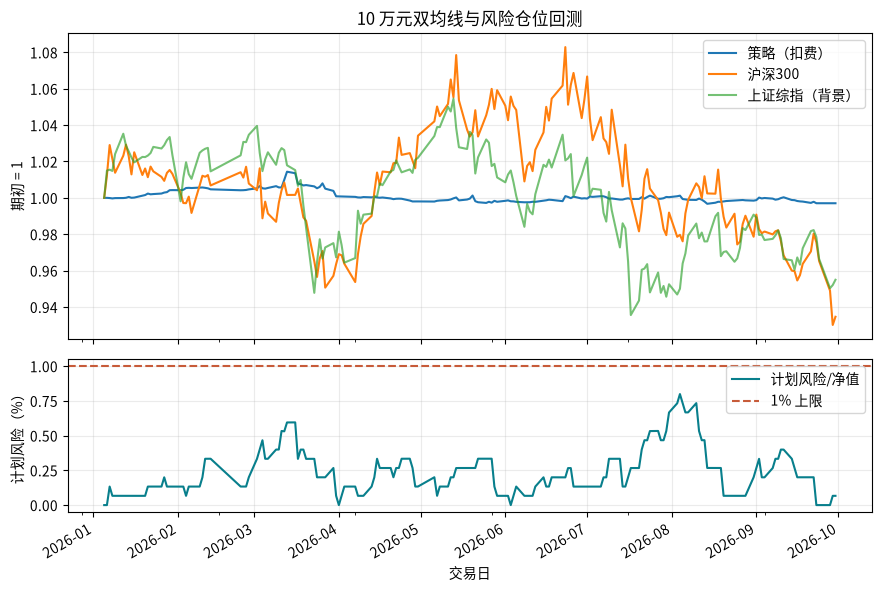

In [9]:
shanghai = shanghai_raw.copy()
shanghai['date'] = pd.to_datetime(shanghai['date'])
shanghai['close'] = pd.to_numeric(shanghai['close'])
shanghai = shanghai.set_index('date')['close'].reindex(nav.index)
shanghai = shanghai / shanghai.iloc[0]
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
nav[['nav', 'benchmark_nav']].rename(columns={
    'nav': '策略（扣费）', 'benchmark_nav': '沪深300'}).plot(ax=axes[0])
shanghai.plot(ax=axes[0], label='上证综指（背景）', alpha=.65)
axes[0].set(ylabel='期初 = 1', title='10 万元双均线与风险仓位回测')
axes[0].grid(alpha=.25); axes[0].legend()
(nav.planned_risk_pct * 100).plot(ax=axes[1], color='#087f8c', label='计划风险/净值')
axes[1].axhline(TOTAL_RISK * 100, color='#c75b39', linestyle='--', label='1% 上限')
axes[1].set(ylabel='计划风险（%）', xlabel='交易日')
axes[1].grid(alpha=.25); axes[1].legend()
fig.tight_layout(); plt.show()

## 模块 8｜可选：每阶段交易 GIF

每帧对应一个 7 交易日调池阶段，列出买卖股票名称、方向、**复权单位**与**模拟金额**。加仓会在买入侧累计，触发原因见 `trades.reason`，首次与最近一次买价可查 `holdings`。这只是账本可视化，不是实盘订单。

26 个阶段，110 条阶段交易汇总


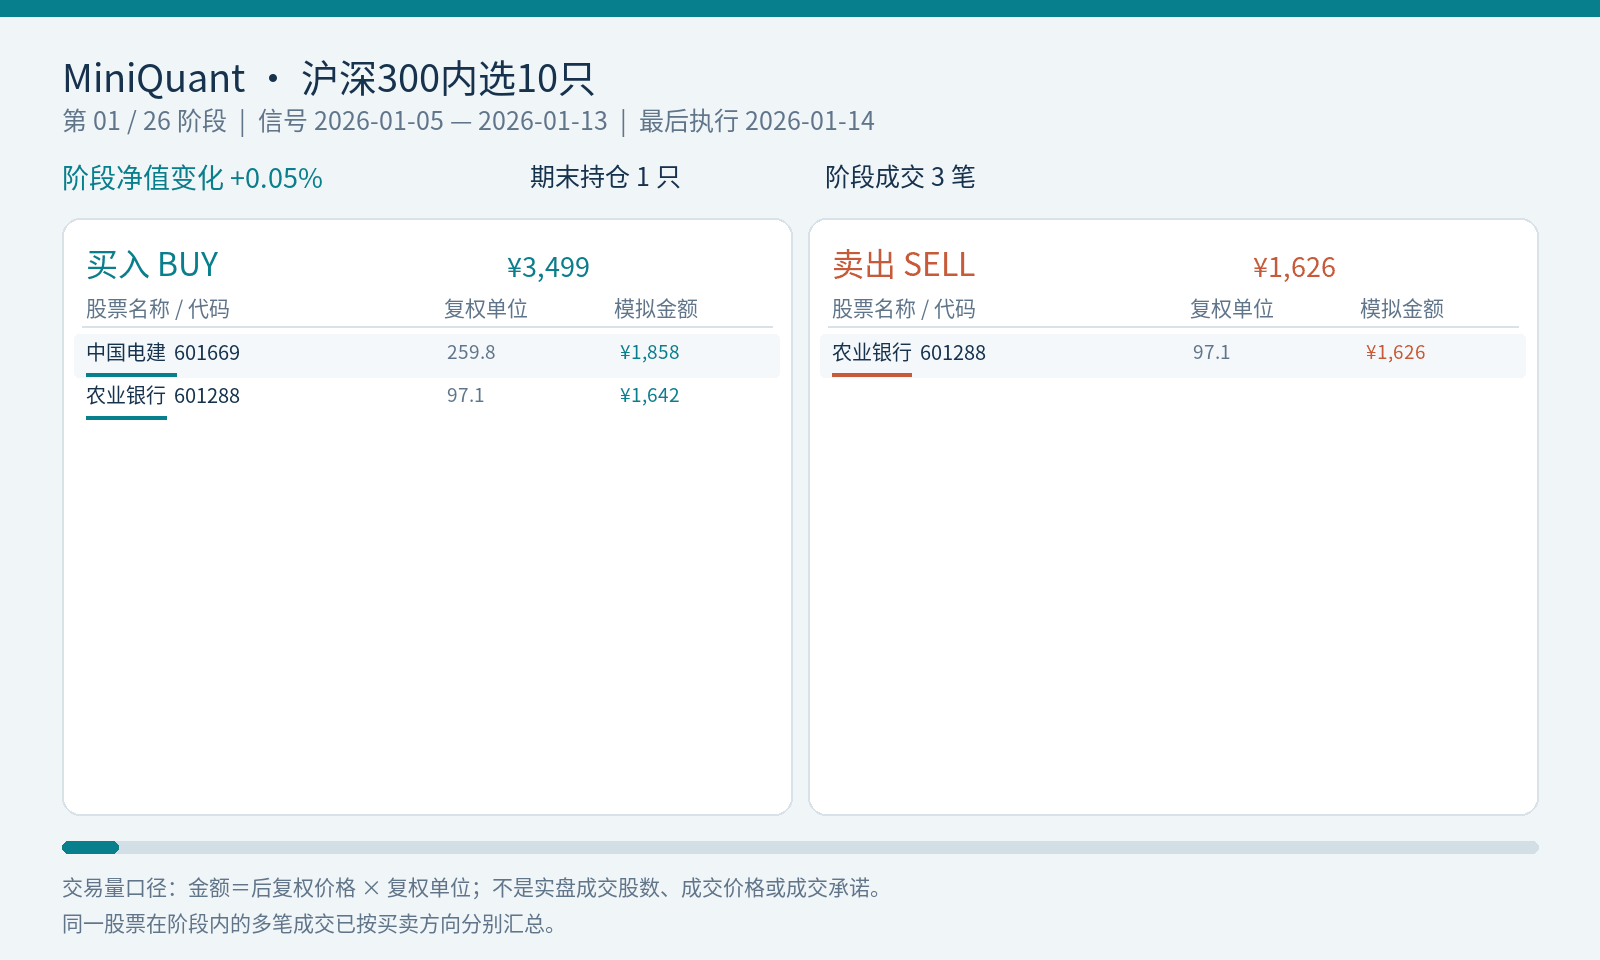

In [10]:
from PIL import Image, ImageDraw, ImageFont

FONT = Path('video/assets/NotoSansCJKsc-Regular.otf')
SIZE = (1600, 960)
INK, MUTED, BUY, SELL = '#17324d', '#60758a', '#087f8c', '#c75b39'

def phase_trade_table(trades: pd.DataFrame, decisions: pd.DataFrame,
                      members: pd.DataFrame) -> pd.DataFrame:
    """Aggregate every executed order by seven-day phase, side and stock."""
    starts = pd.to_datetime(decisions.loc[decisions["rebalance"], "signal_date"])
    if starts.empty or not starts.is_monotonic_increasing:
        raise ValueError("Missing or unordered phase boundaries")
    frame = trades.copy()
    frame["phase"] = np.searchsorted(starts.to_numpy(), frame["signal_date"].to_numpy(), side="right") - 1
    if (frame["phase"] < 0).any() or (frame["phase"] >= len(starts)).any():
        raise ValueError("A trade has no matching phase")
    if not (frame["date"] > frame["signal_date"]).all():
        raise ValueError("Trade preceded its signal")
    frame["notional"] = frame["units"] * frame["adjusted_price"]
    names = members.drop_duplicates("code").set_index("code")["code_name"]
    frame["name"] = frame["code"].map(names)
    if frame["name"].isna().any() or not frame["notional"].gt(0).all():
        raise ValueError("Missing stock name or nonpositive simulated trade amount")
    result = frame.groupby(["phase", "side", "code", "name"], as_index=False).agg(
        adjusted_units=("units", "sum"),
        simulated_notional=("notional", "sum"),
        executions=("code", "size"),
    )
    if not np.isclose(result["simulated_notional"].sum(), frame["notional"].sum()):
        raise ValueError("Animated trade amounts do not reconcile to the ledger")
    return result.sort_values(["phase", "side", "simulated_notional"],
                              ascending=[True, True, False]).reset_index(drop=True)


def _font(size: int) -> ImageFont.FreeTypeFont:
    if not FONT.exists():
        raise FileNotFoundError(f"Bundled Chinese font missing: {FONT.name}")
    return ImageFont.truetype(str(FONT), size)


def _money(amount: float) -> str:
    if amount >= 10_000:
        return f"¥{amount / 10_000:,.1f} 万"
    return f"¥{amount:,.0f}"


def _side(draw: ImageDraw.ImageDraw, rows: pd.DataFrame, *, left: int,
          title: str, color: str, max_rows: int, max_notional: float) -> None:
    draw.rounded_rectangle((left, 218, left + 730, 815), radius=18,
                           fill="#ffffff", outline="#d9e2e9", width=2)
    draw.text((left + 24, 238), title, font=_font(32), fill=color)
    amount = rows["simulated_notional"].sum()
    draw.text((left + 445, 245), _money(amount), font=_font(27), fill=color)
    draw.text((left + 24, 291), "股票名称 / 代码", font=_font(21), fill=MUTED)
    draw.text((left + 382, 291), "复权单位", font=_font(21), fill=MUTED)
    draw.text((left + 552, 291), "模拟金额", font=_font(21), fill=MUTED)
    draw.line((left + 20, 326, left + 710, 326), fill="#d9e2e9", width=2)
    if rows.empty:
        draw.text((left + 250, 517), "本阶段无成交", font=_font(27), fill=MUTED)
        return
    row_height = min(43, 474 // max_rows)
    for i, row in enumerate(rows.itertuples(index=False)):
        y = 336 + i * row_height
        if i % 2 == 0:
            draw.rounded_rectangle((left + 12, y - 2, left + 717, y + row_height - 2),
                                   radius=5, fill="#f5f8fa")
        code = row.code.split(".")[-1]
        draw.text((left + 24, y), f"{row.name}  {code}", font=_font(20), fill=INK)
        draw.text((left + 385, y), f"{row.adjusted_units:,.1f}", font=_font(19), fill=MUTED)
        draw.text((left + 558, y), _money(row.simulated_notional), font=_font(19), fill=color)
        bar_width = int(300 * row.simulated_notional / max_notional)
        draw.rectangle((left + 24, y + row_height - 6,
                        left + 24 + bar_width, y + row_height - 3), fill=color)


def make_trade_animation(trades: pd.DataFrame, decisions: pd.DataFrame,
                         members: pd.DataFrame, nav: pd.DataFrame,
                         out_path: str | Path, duration_ms: int = 2500) -> pd.DataFrame:
    """Save a GIF with one frame per rebalance phase and return its audit table."""
    if duration_ms < 200:
        raise ValueError("Animation duration must allow the table to be read")
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    table = phase_trade_table(trades, decisions, members)
    reset = decisions.reset_index(drop=True)
    boundaries = list(reset.index[reset["rebalance"]]) + [len(reset)]
    max_rows = max(1, int(table.groupby(["phase", "side"]).size().max()))
    if max_rows > 12:
        raise ValueError(f"More than 12 distinct names in a phase side: {max_rows}")
    max_notional = max(float(table["simulated_notional"].max()), 1.0)
    frames = []
    for phase, (begin, stop) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        block = reset.iloc[begin:stop]
        signal_start = block["signal_date"].iloc[0]
        signal_end = block["signal_date"].iloc[-1]
        executed_end = block["execution_date"].iloc[-1]
        phase_nav = nav.loc[executed_end, "nav"] / nav.loc[signal_start, "nav"] - 1
        holdings = int(nav.loc[executed_end, "holdings"])
        selected = table.loc[table["phase"] == phase]
        buys = selected.loc[selected["side"] == "BUY"]
        sells = selected.loc[selected["side"] == "SELL"]

        image = Image.new("RGB", SIZE, "#f0f5f8")
        draw = ImageDraw.Draw(image)
        draw.rectangle((0, 0, SIZE[0], 16), fill=BUY)
        draw.text((62, 47), "MiniQuant · 沪深300内选10只", font=_font(38), fill=INK)
        draw.text((62, 101),
                  f"第 {phase + 1:02d} / {len(boundaries)-1:02d} 阶段  |  信号 {signal_start.date()} — {signal_end.date()}"
                  f"  |  最后执行 {executed_end.date()}", font=_font(25), fill=MUTED)
        gain_color = BUY if phase_nav >= 0 else SELL
        draw.text((62, 156), f"阶段净值变化 {phase_nav:+.2%}", font=_font(27), fill=gain_color)
        draw.text((530, 157), f"期末持仓 {holdings} 只", font=_font(25), fill=INK)
        draw.text((825, 157), f"阶段成交 {int(selected['executions'].sum())} 笔", font=_font(25), fill=INK)
        _side(draw, buys, left=62, title="买入 BUY", color=BUY,
              max_rows=max_rows, max_notional=max_notional)
        _side(draw, sells, left=808, title="卖出 SELL", color=SELL,
              max_rows=max_rows, max_notional=max_notional)
        progress = (phase + 1) / (len(boundaries) - 1)
        draw.rounded_rectangle((62, 841, 1538, 853), radius=6, fill="#d2dfe7")
        draw.rounded_rectangle((62, 841, 62 + int(1476 * progress), 853),
                               radius=6, fill=BUY)
        draw.text((62, 870),
                  "交易量口径：金额＝后复权价格 × 复权单位；不是实盘成交股数、成交价格或成交承诺。",
                  font=_font(21), fill=MUTED)
        draw.text((62, 906), "同一股票在阶段内的多笔成交已按买卖方向分别汇总。",
                  font=_font(21), fill=MUTED)
        frames.append(image.convert("P", palette=Image.Palette.ADAPTIVE, colors=128))
    temp = out_path.with_name(out_path.stem + ".part.gif")
    frames[0].save(temp, save_all=True, append_images=frames[1:],
                   duration=duration_ms, loop=0, optimize=True, disposal=2)
    temp.replace(out_path)
    return table


gif_path = Path('figs/simple_framework_trades.gif')
phase_trades = make_trade_animation(trades, decisions, members, nav, gif_path)
print(f'{int(decisions.rebalance.sum())} 个阶段，{len(phase_trades)} 条阶段交易汇总')
display(NotebookImage(filename=str(gif_path), embed=True))

## 如何理解这次结果

本例在 **2026-01-05 至 2026-09-30** 样本内测试 10 万元、MA5/MA20、计划风险预算、盈利达到 +2%/+4% 后的等额加仓和浮动止盈止损。本次默认 +2%/+4% 加仓在样本内约亏 **0.30%**，虽然跑赢了下跌的沪深 300，但没有实现绝对盈利。阈值敏感性表只是同样本对比，不能挑出略微为正的一行就宣称有稳定 Alpha。结果以**实际运行的表格**为准。固定初始成分股、财报历史修订、后复权价、分数复权单位、未模拟 A 股整手/涨跌停和跳空成交，都会影响实盘。**计划风险 1% 不等于最大回撤 1%，也不保证单笔只亏 3%。**

**来源**：[BaoStock 官网/API](https://www.baostock.com/) · [BaoStock 复权说明](https://www.baostock.com/helpdocs/pdf/BaoStock%E5%A4%8D%E6%9D%83%E5%9B%A0%E5%AD%90%E7%AE%80%E4%BB%8B.pdf) · [东方财富财报数据中心](https://data.eastmoney.com/bbsj/)。公开仓库不打包原始网页数据，首次运行会缓存到 `data/private/`。

费率来源：[上交所股票交易费用说明](https://one.sse.com.cn/onething/gptz/)列出卖出印花税 0.5‰、过户费 0.01‰ 和佣金最低 5 元；[财政部与税务总局 2023 年公告](https://szs.mof.gov.cn/zhengcefabu/202308/t20230827_3904226.htm)规定证券交易印花税减半。佣金万三只是本例假设，请按自己的券商账户修改。